In [69]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")


In [70]:
# ==============================
# 2. LOAD DATA
# ==============================

df = pd.read_csv("Walmart.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [71]:
# ==============================
# 3. DATA INSPECTION
# ==============================

df.info()
df.describe()

# Check missing values

print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB

Missing Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [72]:
# ==============================
# 4. DATA CLEANING
# ==============================

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Sort by Date (VERY IMPORTANT for time series)
df = df.sort_values('Date').reset_index(drop=True)

# Drop duplicates if any
df = df.drop_duplicates()

# Forward fill missing values
df = df.ffill()

# Encode store as numeric
df['Store'] = df['Store'].astype('category').cat.codes

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,0,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,9,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
2,36,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
3,16,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4,29,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


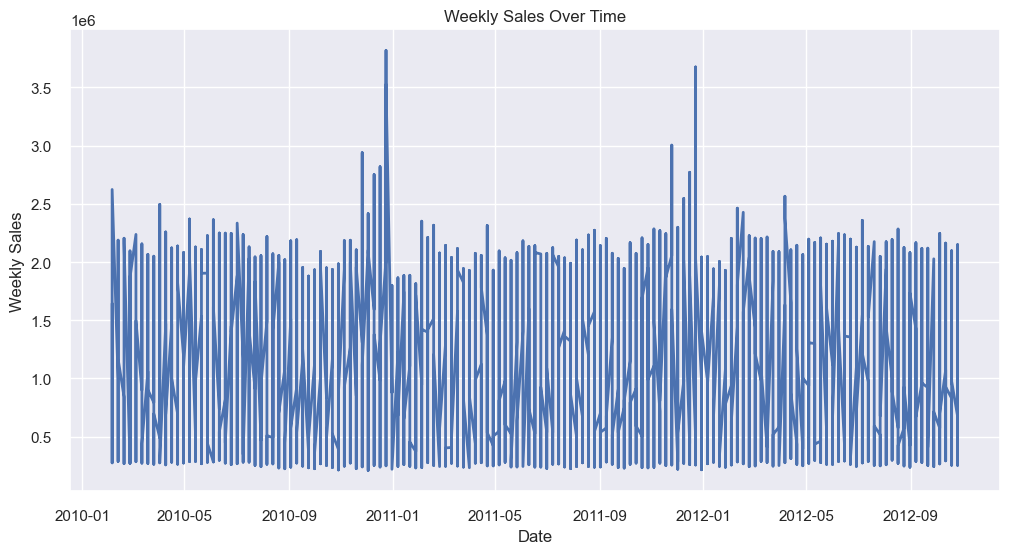

In [73]:
# ==============================
# 5. VISUALIZE SALES TREND
# ==============================

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Weekly_Sales'], linewidth=2)
plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(True)
plt.show()

In [74]:
# ==============================
# 6. FEATURE ENGINEERING
# ==============================

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
df['dayofweek'] = df['Date'].dt.dayofweek

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week_of_year,dayofweek
0,0,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,4
1,9,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5,4
2,36,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5,4
3,16,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5,4
4,29,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5,4


In [75]:
# ==============================
# 7. CREATE LAG FEATURES
# ==============================

df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_4'] = df['Weekly_Sales'].shift(4)
df['lag_12'] = df['Weekly_Sales'].shift(12)

# Rolling mean using past values only (avoids data leakage)
df['rolling_mean_4'] = df['Weekly_Sales'].shift(1).rolling(4).mean()

# Drop rows with NaN created by lag features
df = df.dropna()

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week_of_year,dayofweek,lag_1,lag_4,lag_12,rolling_mean_4
12,38,2010-02-05,1230596.80,0,44.30,2.572,209.852966,8.554,2010,2,5,4,1034119.21,1388725.63,1643690.90,1.182269e+06
13,7,2010-02-05,1004137.09,0,34.14,2.572,214.471451,6.299,2010,2,5,4,1230596.80,1507637.17,2193048.75,1.142737e+06
14,31,2010-02-05,1087616.19,0,34.43,2.580,189.381697,9.014,2010,2,5,4,1004137.09,798593.88,536006.73,1.016862e+06
15,14,2010-02-05,652122.44,0,19.83,2.954,131.527903,8.350,2010,2,5,4,1087616.19,1034119.21,789036.02,1.089117e+06
16,33,2010-02-05,956228.96,0,35.44,2.598,126.442065,9.521,2010,2,5,4,652122.44,1230596.80,465108.52,9.936181e+05


In [76]:
# ==============================
# 8. TRAIN-TEST SPLIT
# ==============================

split_date = df['Date'].max() - pd.DateOffset(months=6)

train = df[df['Date'] <= split_date].copy()
test = df[df['Date'] > split_date].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (5208, 16)
Test shape: (1215, 16)


In [77]:
print(train['Date'].min(), "→", train['Date'].max())
print(test['Date'].min(), "→", test['Date'].max())

2010-02-05 00:00:00 → 2012-04-20 00:00:00
2012-04-27 00:00:00 → 2012-10-26 00:00:00


In [78]:
print(train.columns)

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week_of_year',
       'dayofweek', 'lag_1', 'lag_4', 'lag_12', 'rolling_mean_4'],
      dtype='object')


In [79]:
# ==============================
# 9. DEFINE FEATURES
# ==============================

features = [
    'lag_1','lag_4','lag_12',
    'rolling_mean_4',
    'month','week_of_year','year',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Store'
]

X_train = train[features].copy()
y_train = train['Weekly_Sales'].copy()

X_test = test[features].copy()
y_test = test['Weekly_Sales'].copy()

In [80]:
# ==============================
# 10. TRAIN MODEL
# ==============================

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

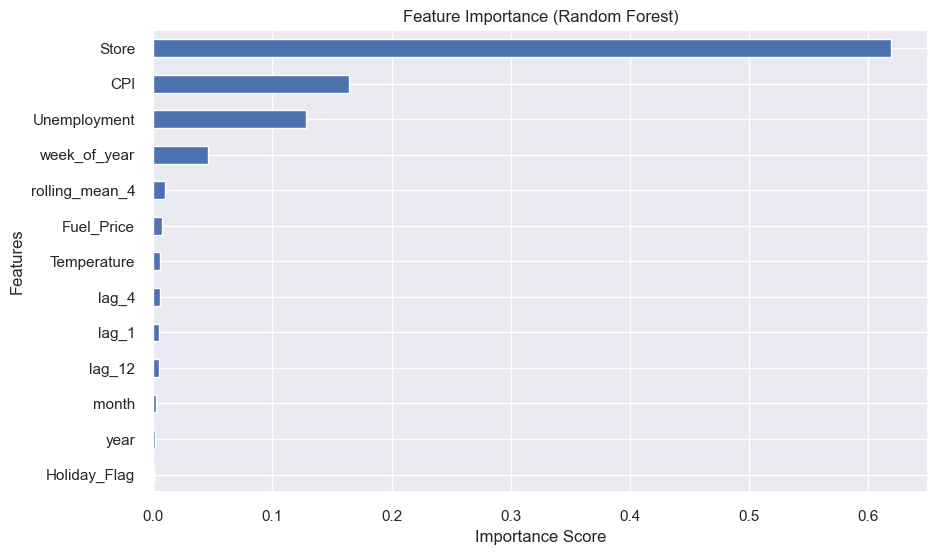

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)

plt.figure(figsize=(10,6))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [93]:
# ==============================
# 11. PREDICTION
# ==============================

predictions = model.predict(X_test)

# Attach predictions to test dataframe
test['Predicted_Sales'] = predictions

In [94]:
# ==============================
# 12. EVALUATION
# ==============================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 85,218.70
RMSE : 161,563.27
R2   : 0.9085


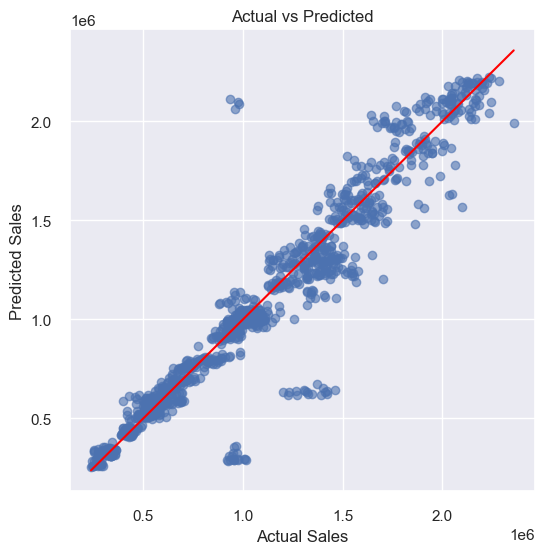

In [95]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

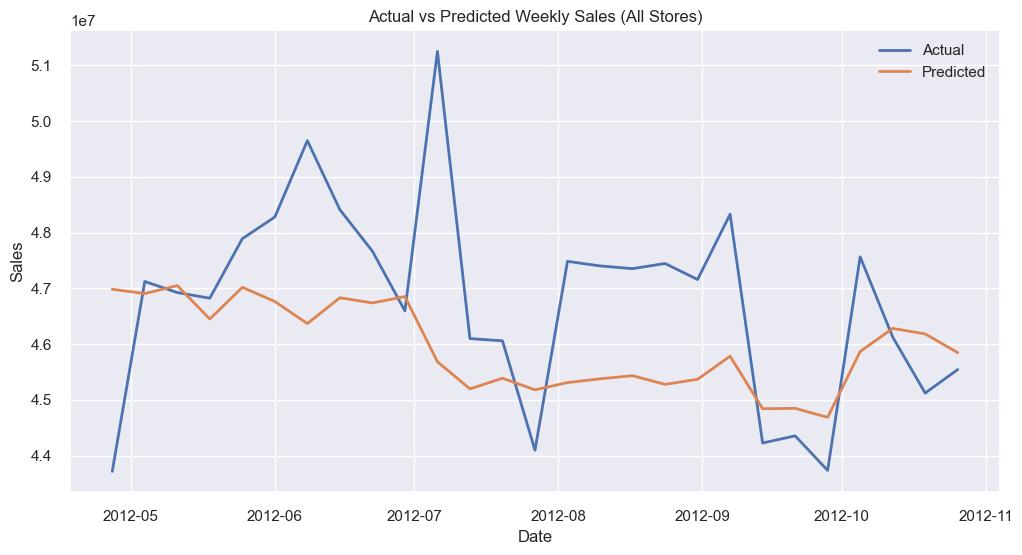

In [98]:
# ================================
# 13. VISUALIZE RESULTS (AGGREGATED)
# ================================

# Attach predictions
test["Predicted"] = predictions

# Aggregate by date (sum across stores)
plot_df = (
    test.groupby("Date")[["Weekly_Sales", "Predicted"]]
    .sum()
    .reset_index()
    .sort_values("Date")
)

plt.figure(figsize=(12,6))

plt.plot(plot_df["Date"], plot_df["Weekly_Sales"],
         label="Actual", linewidth=2)

plt.plot(plot_df["Date"], plot_df["Predicted"],
         label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Weekly Sales (All Stores)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

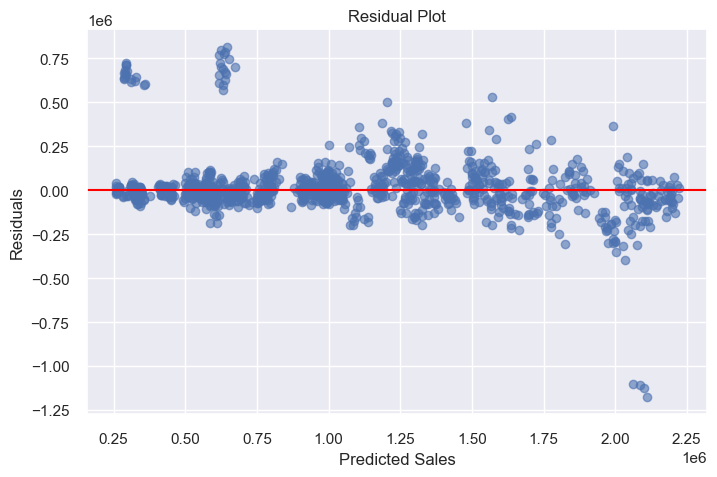

In [99]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals, alpha=0.6)

plt.axhline(0, color='red')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

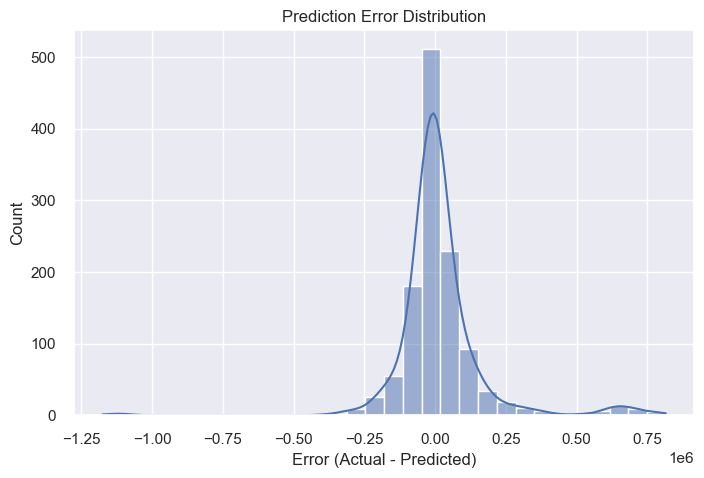

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")

plt.show()

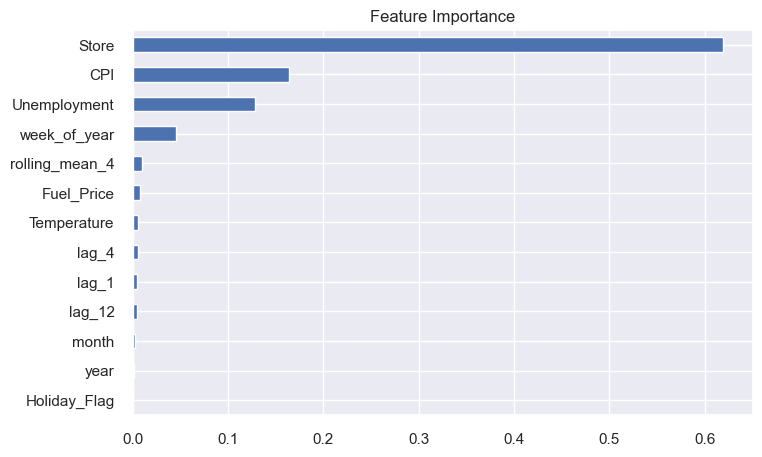

In [101]:
# ==============================
# 14. FEATURE IMPORTANCE
# ==============================

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()


In [104]:
import joblib

joblib.dump(model, "sales_forecast_model.pkl")
print("Model saved as sales_forecast_model.pkl")


Model saved as sales_forecast_model.pkl


In [105]:
import pandas as pd
import joblib

# load trained model
model = joblib.load("sales_forecast_model.pkl")

# load data
df = pd.read_csv("Walmart.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

# recreate features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_4'] = df['Weekly_Sales'].shift(4)
df['lag_12'] = df['Weekly_Sales'].shift(12)
df['rolling_mean_4'] = df['Weekly_Sales'].shift(1).rolling(4).mean()

df = df.dropna()

In [120]:
latest_row = df.iloc[-1]

test_input = pd.DataFrame({
    'lag_1': [latest_row['lag_1']],
    'lag_4': [latest_row['lag_4']],
    'lag_12': [latest_row['lag_12']],
    'rolling_mean_4': [latest_row['rolling_mean_4']],
    'month': [latest_row['month']],
    'week_of_year': [latest_row['week_of_year']],
    'year': [latest_row['year']],
    'Holiday_Flag': [latest_row['Holiday_Flag']],
    'Temperature': [latest_row['Temperature']],
    'Fuel_Price': [latest_row['Fuel_Price']],
    'CPI': [latest_row['CPI']],
    'Unemployment': [latest_row['Unemployment']],
    'Store': [latest_row['Store']]
})

prediction = model.predict(test_input)

print(f"Predicted Sales: {prediction[0]:,.2f}")
print(f"Actual Sales:    {latest_row['Weekly_Sales']:,.2f}")

Predicted Sales: 768,606.65
Actual Sales:    760,281.43


## Model Insights and Conclusion

Key Findings

• Store identity is the strongest predictor of weekly sales.
• Economic indicators such as CPI and unemployment significantly influence demand.
• Seasonal patterns captured by week_of_year contribute moderately.
• Lag-based features provide limited additional signal when store-level differences dominate.

Model Performance

• The model successfully captures overall demand patterns across stores.
• Predictions closely follow the general sales trend.
• Extreme sales spikes are slightly smoothed due to the averaging nature of Random Forest.

Future Improvements

• Train separate models for each store to better capture temporal dynamics.
• Try Gradient Boosting or XGBoost models.
• Include promotional campaign data and holiday events.